In [2]:
import clusim.sim as sim
from clusim.clustering import Clustering
import numpy as np
# conda activate SPACEL
def cons_coef(adata1, adata2, cluster1, cluster2, return_all=True, alpha=.9):
    obs_names = adata1.obs_names
    c1 = Clustering(elm2clu_dict = {index: [value] for index, value in zip(obs_names, adata1.obs[cluster1])})
    
    c2 = Clustering(elm2clu_dict = {index: [value] for index, value in zip(obs_names, adata2.obs[cluster2])})
    sis, relabeled_elements = sim.element_sim_elscore(c1, c2, alpha=alpha)
    
    sis_mapped = np.zeros(len(obs_names))

    for obs_index, score_position in relabeled_elements.items():
        sis_mapped[obs_names.get_loc(obs_index)] = sis[score_position]
        
    if return_all:
        return sis_mapped, np.mean(sis_mapped)
    else:
        return sis_mapped

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix
from scipy.spatial.distance import *
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import scanpy as sc
import os, os.path as osp
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn import metrics
methods = ['Seurat', 'CARD', 'cell2location', 'GraphST', 'DestVI','RCTD', 'scVI', 'SingleR', 'spatialDWLS', 'spatialID','spotlight','tacco','Tangram']
from sklearn.metrics import adjusted_rand_score
def ASW_score(X, pred_labels):
    d = squareform(pdist(X))
    return silhouette_score(X=d,labels=pred_labels,metric='precomputed')
out_rows = []   
ad_train = sc.read_h5ad('/maiziezhou_lab2/yuling/MERFISH_spinal_cord_resolved_0718.h5ad')
st_data = ad_train[ad_train.obs['Section ID'] == '0503_F4_C',]
for m in methods: 
    i = 17
    pred_label = pd.read_csv(f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/{m}/0503_F4_C_output/merged_pred_{i}.csv', index_col=0)
    
    X = st_data.obsm['spatial']
    y_true = pred_label['MERFISH cell type annotation'].astype(str).to_numpy()
    y_pred = pred_label['pred'].astype(str).to_numpy()
    st_data.obs['pred'] = y_pred
    #y_true = np.char.replace(y_true, '_', '/')
    #y_pred = np.char.replace(y_pred, '_', '/')
    labels = np.unique(y_true)  # ensure we average over true classes
    precision_macro = precision_score(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )

    labels = np.unique(np.concatenate([y_true, y_pred]))
    le = LabelEncoder().fit(labels)
    yt = le.transform(y_true)
    yp = le.transform(y_pred)
    mask = (yt == yp)
    n_correct = np.count_nonzero(mask)   
    n_total = mask.size
    acc = n_correct / n_total
    X = st_data.obsm['spatial']
    asw = ASW_score(X=X, pred_labels= y_pred)
    print(f"correct: {n_correct}/{n_total} ({acc:.2%})")
    asw = (asw + 1.0) / 2.0
    asw = max(0.0, min(1.0, float(asw)))
    runtime_file = (
        f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/'
        f'{m}/0503_F4_C_output/runtimeSec_memoryMiB.csv'
    )

    time_ = 0.0
    memory_ = 0.0

    if os.path.exists(runtime_file):
        try:
            rt_df = pd.read_csv(runtime_file)
            time_ = float(rt_df['runtime_sec'].iloc[0])
            memory_ = float(rt_df['peak_memory_MiB'].iloc[0])
        except Exception as e:
            print(f"[Warning] Failed to read runtime file for {m}, set to 0: {e}")
            
    f1_macro    = f1_score(yt, yp, average='macro')
    f1_weighted = f1_score(yt, yp, average='weighted')
    f1_micro    = f1_score(yt, yp, average='micro')  
    sis_map, mean_val = cons_coef(st_data, st_data, 'MERFISH cell type annotation', 'pred', return_all=True, alpha=.9)
    ari = adjusted_rand_score(yp, yt)
    recall_macro = recall_score(y_true, y_pred, average="macro") 
    ami = metrics.adjusted_mutual_info_score(y_true, y_pred)
    nmi = metrics.normalized_mutual_info_score(y_true, y_pred)
    avgbio = (nmi + ari + asw) / 3.0 if np.isfinite(asw) else np.nan
    out_rows.append({
        'Method': m, 
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_micro': f1_micro,
        'precision': precision_macro,
        'recall': recall_macro,
        'ARI': ari,
        'AMI': ami,
        'NMI': nmi,
        'ASW': asw,
        'AvgBIO': avgbio,
        'ECS': mean_val,
        'Time':time_,
        'Memory': memory_
    })

        # Save to CSV
    results_df = pd.DataFrame(out_rows)
    output_path = f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/0503_F4_C/metrics_results.csv'
    results_df.to_csv(output_path, index=False)
    print(f"\nResults saved to: {output_path}")

    # Display the results nicely
    print("\nMetrics Summary:")
    print(results_df.to_string(index=False))

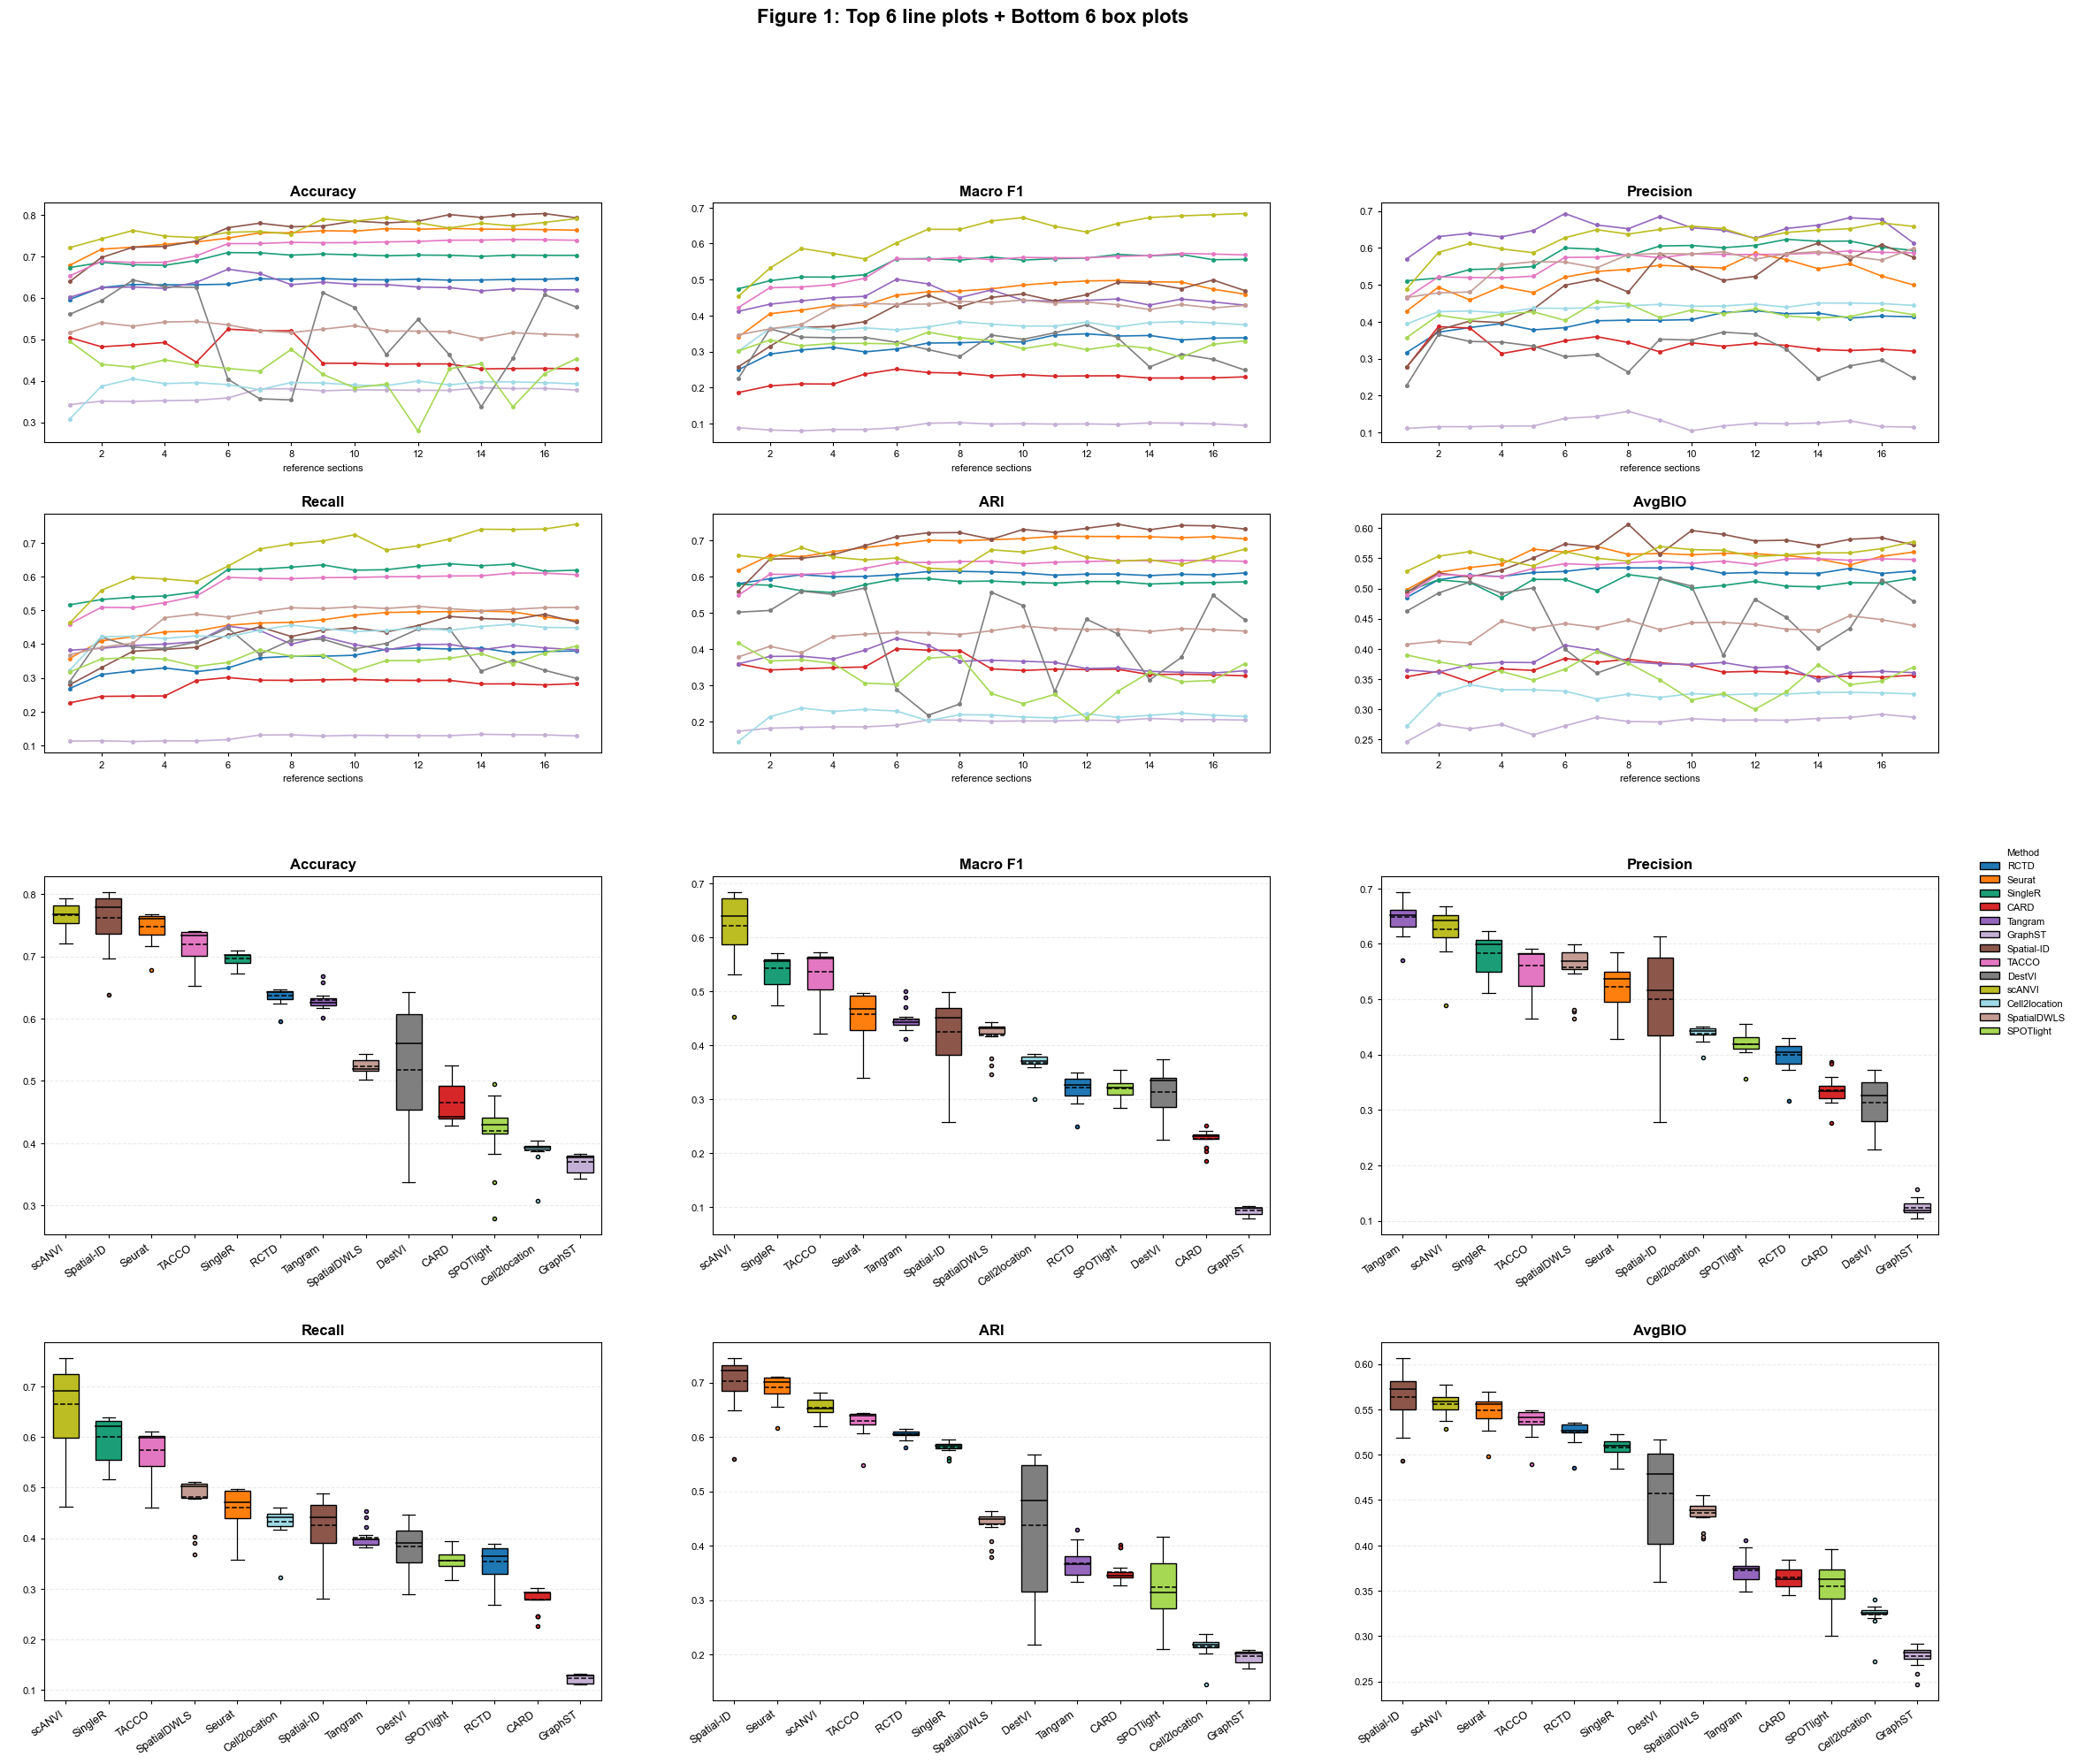

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Figure1aAnd_Figure1b_top_line_bottom_6box.pdf
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Accuracy_ranking.csv
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Macro F1_ranking.csv
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Precision_ranking.csv
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/Recall_ranking.csv
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/ARI_ranking.csv
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/AvgBIO_ranking.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ---- editable text in Illustrator ----
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "text.usetex": False,
})

paths = {
    'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/0503_F4_C_metric/metrics_results_0413.csv',
    'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/0503_F4_C_metric/metrics_results_0413.csv',
    'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/0503_F4_C_metric/metrics_results_0413.csv',
    'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/0503_F4_C_metric/metrics_results_0413.csv',
    'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/0503_F4_C_metric/metrics_results_0413.csv',
    'GraphST': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/0503_F4_C_metric/metrics_results_0413.csv',
    'Spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/0503_F4_C_metric/metrics_results_0413.csv',
    'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/0503_F4_C_metric/metrics_results_0413.csv',
    'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/0503_F4_C_metric/metrics_results_0413.csv',
    'scANVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/0503_F4_C_metric/metrics_results_0413.csv',
    'Cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/0503_F4_C_metric/metrics_results_0413.csv',
    'SpatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/0503_F4_C_metric/metrics_results_0413.csv',
    'SPOTlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/0503_F4_C_metric/metrics_results_0413.csv',
}

colors = {
    'RCTD': '#1f77b4',
    'Seurat': '#ff7f0e',
    'SingleR': '#1b9e77',
    'CARD': '#d62728',
    'Tangram': '#9467bd',
    'GraphST': '#c5b0d5',
    'Spatial-ID': '#8c564b',
    'TACCO': '#e377c2',
    'DestVI': '#7f7f7f',
    'scANVI': '#bcbd22',
    'Cell2location': '#9edae5',
    'SpatialDWLS': '#c49c94',
    'SPOTlight': '#A6D854'
}

metric_panels = [
    ("Accuracy", "accuracy"),
    ("Macro F1", "f1_macro"),
    ("Precision", "precision"),
    ("Recall", "recall"),
    ("ARI", "ARI"),
    ("AvgBIO", "AvgBIO"),
]

# ---- load all csv ----
dfs = {}
skipped = []
for name, p in paths.items():
    try:
        d = pd.read_csv(p)
        d['series'] = pd.to_numeric(d.get('series', np.nan), errors='coerce')
        d.sort_values('series', inplace=True)
        dfs[name] = d
    except Exception as e:
        skipped.append((name, p, str(e)))

if len(dfs) == 0:
    raise RuntimeError("NO SUCCESSFUL CSV")


def color_single_boxes(bp, colors_per_box):
    for box, fc in zip(bp['boxes'], colors_per_box):
        box.set(facecolor=fc, edgecolor='black', alpha=1.0)
    for median in bp['medians']:
        median.set(color='black', linewidth=1.1)
    if 'means' in bp:
        for mean in bp['means']:
            mean.set(color='black', linewidth=1.1, linestyle='--')
    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=0.9)
    for cap in bp['caps']:
        cap.set(color='black', linewidth=0.9)
    for flier, fc in zip(bp['fliers'], colors_per_box[:len(bp['fliers'])]):
        flier.set(marker='o', markerfacecolor=fc, markeredgecolor='black', alpha=1.0, markersize=3)


def apply_uniform_spines(ax, lw=0.8, color='black'):
    """Make all subplot border linewidths consistent across panels."""
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_linewidth(lw)
        ax.spines[side].set_color(color)


fig = plt.figure(figsize=(28, 22), constrained_layout=False)
outer = fig.add_gridspec(2, 1, height_ratios=[1.2, 1.8], hspace=0.18)

# ---------- top panel: 6 line plots (2x3) ----------
gs_top = outer[0].subgridspec(2, 3, wspace=0.20, hspace=0.30)
axes_top = [fig.add_subplot(gs_top[i, j]) for i in range(2) for j in range(3)]

for ax, (title_name, metric_col) in zip(axes_top, metric_panels):
    has_data = False
    for name, d in dfs.items():
        if {'series', metric_col}.issubset(d.columns) and len(d):
            y = pd.to_numeric(d[metric_col], errors='coerce')
            x = pd.to_numeric(d['series'], errors='coerce')
            mask = (~x.isna()) & (~y.isna())
            if mask.sum() == 0:
                continue
            has_data = True
            ax.plot(
                x[mask], y[mask],
                label=name,
                color=colors.get(name),
                linestyle='-',
                marker='o',
                linewidth=1.2,
                markersize=2.6,
            )

    if not has_data:
        ax.set_title(f"{title_name} (no data)", fontsize=11)
        ax.axis('off')
        continue

    ax.set_title(title_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('reference sections', fontsize=8)
    ax.set_ylabel(' ', fontsize=8)
    ax.grid(False)
    apply_uniform_spines(ax, lw=0.8)
    ax.tick_params(axis='both', labelsize=8)

# ---------- bottom panel: 6 boxplots (2x3) ----------
gs_bottom = outer[1].subgridspec(2, 3, wspace=0.20, hspace=0.30)
axes_bottom = [fig.add_subplot(gs_bottom[i, j]) for i in range(2) for j in range(3)]

rank_tables = {}
for ax, (title_name, metric_col) in zip(axes_bottom, metric_panels):
    rows = []
    for name, d in dfs.items():
        if metric_col in d.columns:
            arr = pd.to_numeric(d[metric_col], errors='coerce').dropna().values
            if len(arr) > 0:
                rows.append((name, colors.get(name, '#999999'), arr, float(np.nanmean(arr))))

    if not rows:
        ax.set_title(f"{title_name} (no data)", fontsize=12)
        ax.axis('off')
        continue

    rows.sort(key=lambda t: t[3], reverse=True)
    method_labels = [r[0] for r in rows]
    method_colors = [r[1] for r in rows]
    data_arrays = [r[2] for r in rows]
    means_sorted = [r[3] for r in rows]

    x_positions = np.arange(1, len(data_arrays) + 1)
    bp = ax.boxplot(
        data_arrays,
        positions=x_positions,
        widths=0.6,
        showmeans=True,
        meanline=True,
        whis=1.5,
        patch_artist=True,
    )
    color_single_boxes(bp, method_colors)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(method_labels, rotation=35, ha='right', fontsize=9)
    ax.set_title(title_name, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    apply_uniform_spines(ax, lw=0.8)

    rank_tables[title_name] = pd.DataFrame({
        'method': method_labels,
        f'{title_name}_mean': means_sorted,
    })

# one shared legend on right
legend_handles = [Patch(facecolor=colors[m], edgecolor='black', alpha=1.0, label=m)
                  for m in paths if m in colors]
fig.legend(
    handles=legend_handles,
    title='Method',
    loc='center left',
    bbox_to_anchor=(0.905, 0.5),
    borderaxespad=0.0,
    ncol=1,
)

fig.subplots_adjust(right=0.89)
fig.suptitle('Figure 1: Top 6 line plots + Bottom 6 box plots', fontsize=16, fontweight='bold')

out_dir = '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric'
os.makedirs(out_dir, exist_ok=True)
out_pdf = f"{out_dir}/Figure1aAnd_Figure1b_top_line_bottom_6box.pdf"
plt.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {out_pdf}")

for metric_name, rank_df in rank_tables.items():
    out_csv = f"{out_dir}/{metric_name}_ranking.csv"
    rank_df.to_csv(out_csv, index=False)
    print(f"Saved ranking: {out_csv}")

if skipped:
    print("\n[INFO] SKIPPED:")
    for name, p, e in skipped:
        print(f"  - {name}: {p} | {e}")

# please change to visualize different metrics: 
for name, d in dfs.items():
    if {'series','ECS'}.issubset(d.columns) and len(d):

"\nplt.figure(figsize=(10, 4))\n\nfor name, d in dfs.items():\n    if {'series','accuracy'}.issubset(d.columns) and len(d):\n        plt.plot(\n            d['series'], d['ARI'],\n            label=name,\n            color=colors.get(name, None),\n            linestyle=linestyles.get(name, '-'),\n            marker=markers.get(name, 'o'),\n            linewidth=1.8,\n            markersize=4\n        )\n\nplt.xlabel('series')\nplt.ylabel('score')\nplt.title('ARI by series, testing 0503_M4_S')\nplt.ylim(0, 0.8)\nplt.grid(True, alpha=0.3)\nplt.legend(title='Method', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, ncol=1)\nplt.tight_layout(rect=[0, 0, 0.82, 1])\nplt.show()\n"

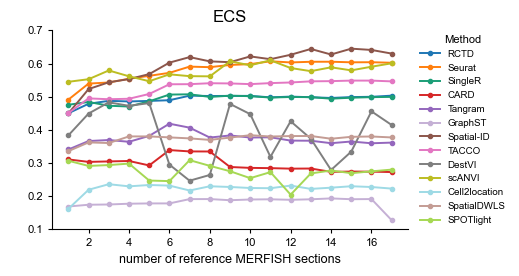

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",     
    "font.size": 8,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # legend
    "legend.frameon": False,
    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
})

paths = {
    'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/0503_F4_C_metric/metrics_results.csv',
    'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/0503_F4_C_metric/metrics_results.csv',
    'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/0503_F4_C_metric/metrics_results.csv',
    'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/0503_F4_C_metric/metrics_results.csv',
    'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/0503_F4_C_metric/metrics_results.csv',
    'GraphST': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/0503_F4_C_metric/metrics_results.csv',
    'Spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/0503_F4_C_metric/metrics_results.csv',
    'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/0503_F4_C_metric/metrics_results.csv',
    'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/0503_F4_C_metric/metrics_results.csv',
    'scANVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/0503_F4_C_metric/metrics_results.csv',
    'Cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/0503_F4_C_metric/metrics_results.csv',
    'SpatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/0503_F4_C_metric/metrics_results.csv',
    'SPOTlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/0503_F4_C_metric/metrics_results.csv',
}

dfs = {name: pd.read_csv(p) for name, p in paths.items()}

# 
for name, d in dfs.items():
    d['series'] = pd.to_numeric(d['series'], errors='coerce')
    d.sort_values('series', inplace=True)
 

colors = {
    'RCTD': '#1f77b4',        # 
    'Seurat': '#ff7f0e',      # 
    'SingleR': '#1b9e77',     # 
    'CARD': '#d62728',        # 
    'Tangram': '#9467bd',     # 
    'GraphST':      '#c5b0d5',  # 
     'Spatial-ID': '#8c564b',
     'TACCO': '#e377c2',   # 
    'DestVI': '#7f7f7f',       # 
   'scANVI': '#bcbd22',      # 
    'Cell2location':'#9edae5',  # 
    'SpatialDWLS':  '#c49c94',  # 
    'SPOTlight': '#A6D854'   # 
}


plt.figure(figsize=(7, 2.8))  

for name, d in dfs.items():
    if {'series','ECS'}.issubset(d.columns) and len(d):
        plt.plot(
            d['series'],
            d['ECS'], # change to f1_macro
            label=name,
            color=colors.get(name),
            linestyle='-',      
            marker='o',         
            linewidth=1.4,      
            markersize=3        
        )

# Axis
plt.xlabel('number of reference MERFISH sections', fontsize=9)
plt.ylabel(' ', fontsize=9)
plt.title('ECS', fontsize= 12, pad=6)

plt.ylim(0.1, 0.7)
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=8)

plt.legend(
    title='Method',
    title_fontsize=8,
    fontsize=7,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    handlelength=2.0
)

plt.tight_layout(rect=[0.05, 0, 0.8, 1])

plt.savefig(
    "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/F1_based/ECS_by_series_0108.pdf",
    bbox_inches="tight"
)

'''
plt.figure(figsize=(10, 4))

for name, d in dfs.items():
    if {'series','accuracy'}.issubset(d.columns) and len(d):
        plt.plot(
            d['series'], d['ARI'],
            label=name,
            color=colors.get(name, None),
            linestyle=linestyles.get(name, '-'),
            marker=markers.get(name, 'o'),
            linewidth=1.8,
            markersize=4
        )

plt.xlabel('series')
plt.ylabel('score')
plt.title('ARI by series, testing 0503_M4_S')
plt.ylim(0, 0.8)
plt.grid(True, alpha=0.3)
plt.legend(title='Method', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, ncol=1)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()
'''